In [2]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [4]:
path = os.getcwd()

for filename in os.listdir(path):

    if filename.endswith(".csv"):
        data = pd.read_csv(filename)
        col_names = data.columns.to_list()
        col_names.remove('Unnamed: 0')
        col_names.remove('Shift')
        col_names.remove('Gap Open')
        col_names.remove('Gap Extension')

   
def wilcoxon_ignore_nan(model_column_values, best_col_vals):
    #convert inputs to numpy arrays for element-wise operations
    model_column_values = np.array(model_column_values)
    best_col_vals = np.array(best_col_vals)

    #filter out pairs where either value is NaN
    valid_indices = ~np.isnan(model_column_values) & ~np.isnan(best_col_vals)
    filtered_model_values = model_column_values[valid_indices]
    filtered_best_values = best_col_vals[valid_indices]

    #perform the Wilcoxon test
    statistic, p_value = wilcoxon(filtered_model_values, filtered_best_values)

    return statistic, p_value


#given 2 lists of the same length, for index i of list 1 and index i of list 2, make a tuple [list_1[i], list_2[i]] and return new list
def pair_lists(list_1, list_2):
    if len(list_1) != len(list_2):
        raise ValueError("Both lists must have the same length.")
    return [[list_1[i], list_2[i]] for i in range(len(list_1))]


def count_color_conditions(datapoints):
    count_x_less_y = sum(1 for x, y in datapoints if x < y)
    count_y_less_equal_x = sum(1 for x, y in datapoints if x > y)
    return count_x_less_y, count_y_less_equal_x

In [5]:
model_A = pd.read_csv("ankh.csv")
model_2 = pd.read_csv("blosum_45.csv")

SSP = []
SEQ = []
POS = []
DD = []
CC = []
IA = []

#for each domain-distance
for element in col_names:

    model_A_column_values = model_A[element].tolist()
    model_2_column_values = model_2[element].tolist()

    statistic, p_value = wilcoxon_ignore_nan(model_A_column_values, model_2_column_values)
    if p_value < 0.01:
    # if p_value < 2:

        #if the p_val is sig 
        #ankh is x_axis, so pass as first parm
        data_points_list = pair_lists(model_A_column_values, model_2_column_values)

        #store the data points
        if "SSP" in element:
            for data_point in data_points_list:
                SSP.append(data_point)

        elif "SEQ" in element:
            for data_point in data_points_list:
                SEQ.append(data_point)

        elif "POS" in element:
            for data_point in data_points_list:
                POS.append(data_point)
        
        elif "DD" in element:
            for data_point in data_points_list:
                DD.append(data_point)
        
        elif "CC" in element:
            for data_point in data_points_list:
                CC.append(data_point)
        
        elif "IA" in element:
            for data_point in data_points_list:
                IA.append(data_point)
           

/Users/juliamalec/anaconda3/envs/cs3000/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


In [6]:
def plot_colored_dot_plot(datapoints, model_2, distance):
    x_vals = [point[0] for point in datapoints]
    y_vals = [point[1] for point in datapoints]

    #assign color based on condition: x < y → green, else red
    colors = ['blue' if x < y else 'red' for x, y in datapoints]

    plt.figure(figsize=(5, 5))
    
    plt.scatter(x_vals, y_vals, c=colors, s=15, alpha=0.8, edgecolor='k')
    plt.xlabel('Ankh')
    plt.ylabel(str(model_2))
    plt.title('BB - ' + str(distance))
    plt.grid(True)

    if x_vals > y_vals:
        max_value = x_vals
    else:
        max_value = y_vals


    plt.xlim(0, max(max_value))
    plt.ylim(0, max(max_value))

    count_x_less_y, count_y_less_equal_x = count_color_conditions(datapoints)



    legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Ankh\n' + str(count_x_less_y),
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w',
           label=str(model_2)+'\n' + str(count_y_less_equal_x),
           markerfacecolor='red', markersize=8),
    ]
    plt.legend(handles=legend_elements, loc = "lower right", fontsize='small')
#     plt.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1, 1))

    plt.plot([0, 1], [0, 1], color='black', linestyle='-', linewidth=2)
#     plt.savefig(str(distance)+"_ANKH_" + str(model_2) + "_method_comparison.png", format="png", bbox_inches="tight", dpi=100)
    plt.savefig(str(distance)+"_ANKH_" + str(model_2) + "_method_comparison.png", format="png", bbox_inches="tight")

    plt.show()

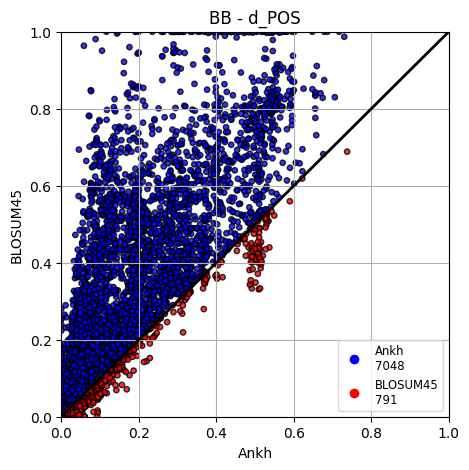

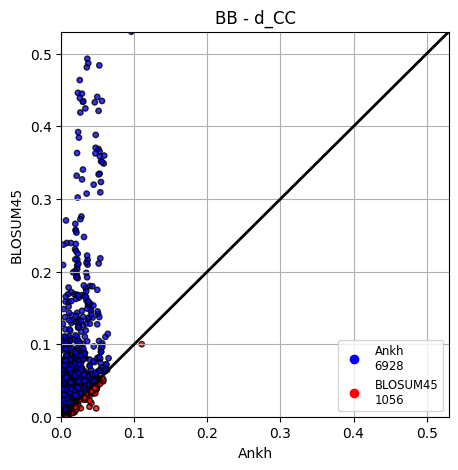

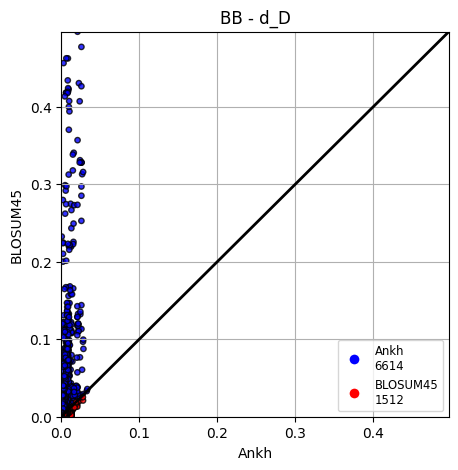

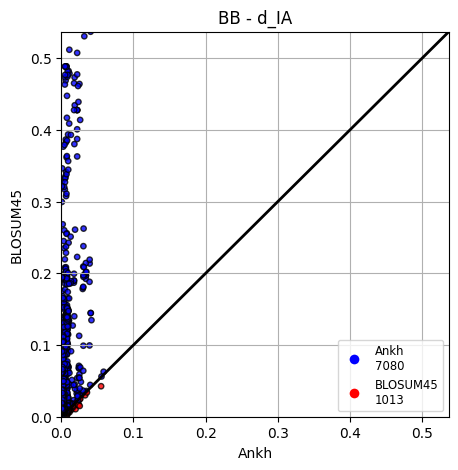

In [7]:
# plot_colored_dot_plot(SSP, "US-align", "d_SSP")
# plot_colored_dot_plot(SEQ, "US-align", "d_SEQ")
plot_colored_dot_plot(POS, "BLOSUM45", "d_POS")
plot_colored_dot_plot(CC, "BLOSUM45", "d_CC")
plot_colored_dot_plot(DD, "BLOSUM45", "d_D")
plot_colored_dot_plot(IA, "BLOSUM45", "d_IA")